## Analise Exploratoria de Dados
---

In [1]:
import pandas as pd
from sqlalchemy import create_engine

In [7]:
# passo 1: leitura do dataset
path = "data/heat_exchanger.db"
engine = create_engine(f"sqlite:///{path}")

df = pd.read_sql("SELECT * FROM heat_exchanger", engine)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['day_index'] = (df['timestamp'] - df['timestamp'].min()).dt.days
df.head()

,timestamp,water_inlet_temperature,glycol_inlet_temperature,out_glycol_temperature,out_water_temperature,heat_efficiency,day_index
0,2025-09-29,33.49,85.82,46.50,61.808856,96.454517,0
1,2025-09-30,33.51,86.35,46.75,61.894941,96.432576,1
2,2025-10-01,33.39,85.98,46.55,61.672872,96.410674,2
3,2025-10-02,33.32,85.71,46.51,61.403079,96.388810,3
4,2025-10-03,32.86,87.54,46.71,61.583481,96.366986,4


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   timestamp                 175 non-null    datetime64[us]
 1   water_inlet_temperature   175 non-null    float64       
 2   glycol_inlet_temperature  175 non-null    float64       
 3   out_glycol_temperature    175 non-null    float64       
 4   out_water_temperature     175 non-null    float64       
 5   heat_efficiency           175 non-null    float64       
 6   day_index                 175 non-null    int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 9.7 KB


In [9]:
# verificar se existem dados faltantes
df.isnull().sum()

timestamp                   0
water_inlet_temperature     0
glycol_inlet_temperature    0
out_glycol_temperature      0
out_water_temperature       0
heat_efficiency             0
day_index                   0
dtype: int64

In [10]:
# verificar estatisticas
df.describe()

,timestamp,water_inlet_temperature,glycol_inlet_temperature,out_glycol_temperature,out_water_temperature,heat_efficiency,day_index
count,175,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000
mean,2025-12-27 08:21:56.571428,31.441943,69.699429,41.350343,51.461277,94.741801,89.348571
min,2025-09-29 00:00:00,20.850000,21.110000,20.700000,21.262971,93.225263,0.000000
25%,2025-11-11 12:00:00,30.910000,31.545000,31.565000,33.128821,93.921594,43.500000
50%,2025-12-27 00:00:00,32.100000,84.130000,45.580000,59.250579,94.691906,89.000000
75%,2026-02-10 12:00:00,32.770000,85.845000,46.485000,60.107158,95.536221,134.500000
max,2026-03-28 00:00:00,35.930000,89.180000,48.970000,64.060976,96.454517,180.000000
std,NaN,2.382263,24.781046,7.686540,13.872204,0.941302,52.465738


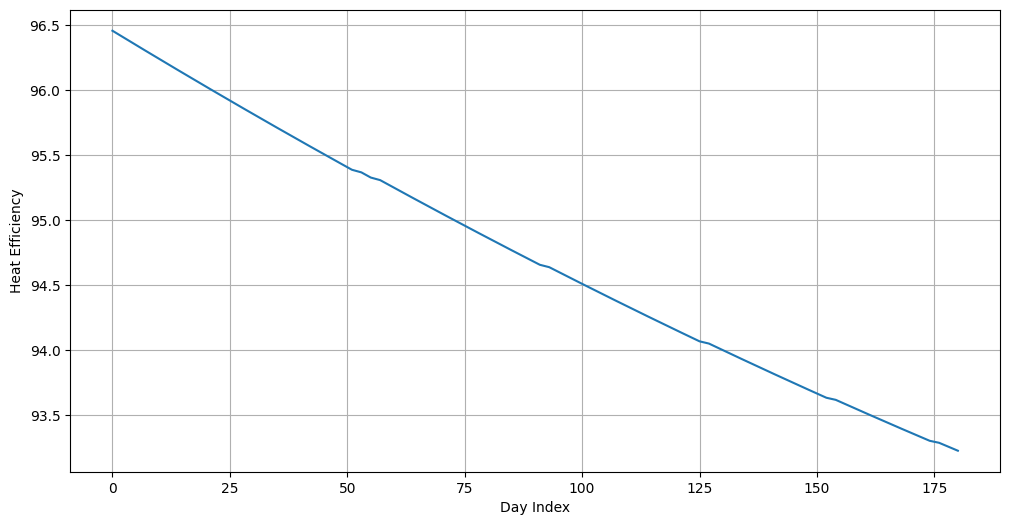

In [14]:
# passo 2: visualização dos dados
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['day_index'], df['heat_efficiency'])
plt.xlabel('Day Index')
plt.ylabel('Heat Efficiency')
plt.grid()
plt.show()

In [34]:
# parte 03: predicao da eficiencia termica
import numpy as np

y = df['heat_efficiency'].values
x = df['day_index'].values

# encontar os coeficientes da reta utilizando numpy
coef = np.polyfit(x, y, 1)
pred = np.polyval(coef, x)

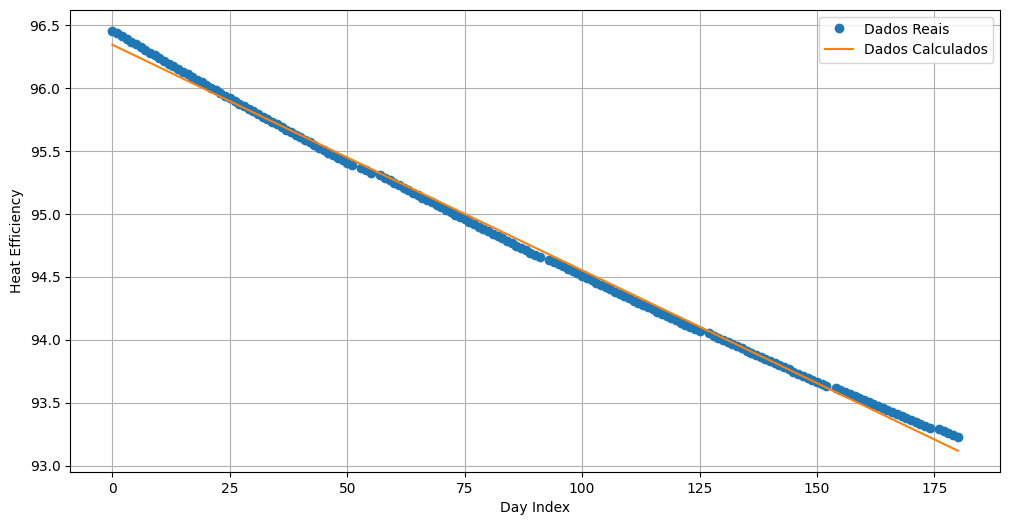

In [35]:
plt.figure(figsize=(12, 6))
plt.plot(df['day_index'], df['heat_efficiency'], 'o', label = "Dados Reais")
plt.plot(x, pred, label = "Dados Calculados")
plt.xlabel('Day Index')
plt.ylabel('Heat Efficiency')
plt.legend()
plt.grid()
plt.show()

In [36]:
# calculo do r2

residuos = y - pred
ss_res = np.sum(residuos**2)
ss_tot = np.sum((y - np.mean(y))**2)

r2 = 1 - (ss_res / ss_tot)
print(r2)

0.9975040682379518
